# Information
## Weather2K: A Multivariate Spatio-Temporal Benchmark Dataset for Meteorological Forecasting Based on Real-Time ObservationDataromdtions

【Accepted】bythe 26th International Conference on Artificial Intelligence and Statistics (AISTATS) 2023**

<a href='[https://arxiv.org/abs/2409.17508](https://arxiv.org/abs/2302.10493)'><img src='https://img.shields.io/badge/Paper-Arxiv-red'></a>  [![GitHub repo](https://img.shields.io/badge/github-repo-green)](https://github.com/Xun-Zhu/weather2k/)  [![Hugging Face](https://img.shields.io/badge/HuggingFace-Dataset-yellow)](https://huggingface.co/datasets/BUPT-PRIS-727/Weather2K)

### Download the dataset

This is the open-source version (after necessary adjustments and checks) of the Weather2K dataset: https://huggingface.co/datasets/BUPT-PRIS-727/Weather2K

The shape of the numpy file of Weather2K-R is (1866, 13, 13632), which means 1,866 groud weather stations, 3 constants for position information and 10 meteorological factors, and 13,632 time steps with 3-hour time resolution (Time coverage range: January 1, 2017- August 31, 2021).



|  Numpy Index   | **Long Name**                             | **Short Name**         | **Unit** |
| :------------: | :---------------------------------------- | :--------------------- | :------: |
|       0        | Latitude                                  | lat                    |   (°)    |
|       1        | Longitude                                 | lon                    |   (°)    |
|       2        | Altitude                                  | alt                    |   (m)    |
|       3        | Air pressure                              | ap                     |   hpa    |
|       4        | Air Temperature                           | t                      |   (°C)   |
|       5        | Maximum temperature                       | mxt                    |   (°C)   |
|       6        | Minimum temperature                       | mnt                    |   (°C)   |
|       7        | Relative humidity                         | rh                     |   (%)    |
|       8        | Precipitation in 3h                       | p3                     |   (mm)   |
|       9        | Wind direction                            | wd                     |   (°)    |
|       10       | Wind speed                                | ws                     | (ms<sup>-1</sup>) |
|       11       | Maximum wind direction                    | mwd                    |   (°)    |
|       12       | Maximum wind speed                        | mws                    | (ms<sup>-1</sup>) |

If you have any quesetions about the data download, please contact wuming@bupt.edu.cn



### Archive

- [Weather2K v1.0](https://github.com/Xun-Zhu/weather2k/tree/v1.0.0)


### Cite

If you are using this dataset please cite 
> Zhu X, Xiong Y, Wu M, et al. Weather2K: A Multivariate Spatio-Temporal Benchmark Dataset for Meteorological Forecasting Based on Real-Time Observation Data from Ground Weather Stations[C]//International Conference on Artificial Intelligence and Statistics. PMLR, 2023: 2704-2722.

In [4]:
"""
Title: Load data and generate train/test sets for SSSD + AFRK model, using Weather 2K dataset
Author: Hsu, Yao-Chih
Version: 1150317
Reference:
"""

# import modules
import os
import re
import xarray as xr
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta

In [5]:
# settning dataset path
dataset_path = f'../../../Weather2K/weather2k.npy'
dataset_path = os.path.abspath(dataset_path)
if os.path.exists(dataset_path):
    print(f'Dataset found: {dataset_path}')
else:
    raise FileNotFoundError(f'Dataset not found: {dataset_path}')

Dataset found: d:\github\Weather2K\weather2k.npy


In [6]:
# load data
data = np.load(dataset_path)

In [7]:
# essential information
print(f'Data shape: {data.shape}')  # (location, feature, time)
print(f'Missing values: {np.sum(np.isnan(data))}')

Data shape: (1866, 13, 13632)
Missing values: 0


In [8]:
# reshape data to (location, time, feature)
data = np.transpose(data, (0, 2, 1))
print(f'Reshaped data shape: {data.shape}')  # (location, time, feature)

Reshaped data shape: (1866, 13632, 13)


In [9]:
# lat and lon and alt
loc = data[:, 0, :3]
print(f'Location shape: {loc.shape}')  # (location, 3)
print(f'Latitude range: {np.min(loc[:,0])} to {np.max(loc[:,0])}')
print(f'Longitude range: {np.min(loc[:,1])} to {np.max(loc[:,1])}')
print(f'Altitude range: {np.min(loc[:,2])} to {np.max(loc[:,2])}')
print(f'locations: \n   lat, lon, alt \n{loc}')
data = data[:, :, 3:]  # remove lat, lon, alt from data
print(f'Data shape after removing loc info: {data.shape}')  # (location, time, feature)

Location shape: (1866, 3)
Latitude range: 18.65 to 53.47
Longitude range: 75.25 to 133.99
Altitude range: -47.2 to 4613.0
locations: 
   lat, lon, alt 
[[ 52.97 122.51 439.7 ]
 [ 53.47 122.38 297.3 ]
 [ 52.35 124.72 363.  ]
 ...
 [ 18.77 109.52 329.7 ]
 [ 18.65 109.7   69.8 ]
 [ 18.8  110.33  41.1 ]]
Data shape after removing loc info: (1866, 13632, 10)


In [10]:
# generate time list
date_start = datetime(2017, 1, 1)
date_end = datetime(2021, 8, 31, 23, 59)

time_list = []
current = date_start

while current <= date_end:
    time_list.append(current)
    current += timedelta(hours=3)
time_list = np.array(time_list)
print(f'start time: {time_list[0]}')
print(f'end time: {time_list[-1]}')
print(f'time points: {len(time_list)}')
print(f'time: {time_list}')

start time: 2017-01-01 00:00:00
end time: 2021-08-31 21:00:00
time points: 13632
time: [datetime.datetime(2017, 1, 1, 0, 0) datetime.datetime(2017, 1, 1, 3, 0)
 datetime.datetime(2017, 1, 1, 6, 0) ...
 datetime.datetime(2021, 8, 31, 15, 0)
 datetime.datetime(2021, 8, 31, 18, 0)
 datetime.datetime(2021, 8, 31, 21, 0)]


In [11]:
# variable list
variable_list = [
    "Air pressure",
    "Air Temperature",
    "Maximum temperature",
    "Minimum temperature",
    "Relative humidity",
    "Precipitation in 3h",
    "Wind direction",
    "Wind speed",
    "Maximum wind direction",
    "Maximum wind speed"
]
print(f'variable count: {len(variable_list)}')
print(f'variables: {variable_list}')

variable count: 10
variables: ['Air pressure', 'Air Temperature', 'Maximum temperature', 'Minimum temperature', 'Relative humidity', 'Precipitation in 3h', 'Wind direction', 'Wind speed', 'Maximum wind direction', 'Maximum wind speed']


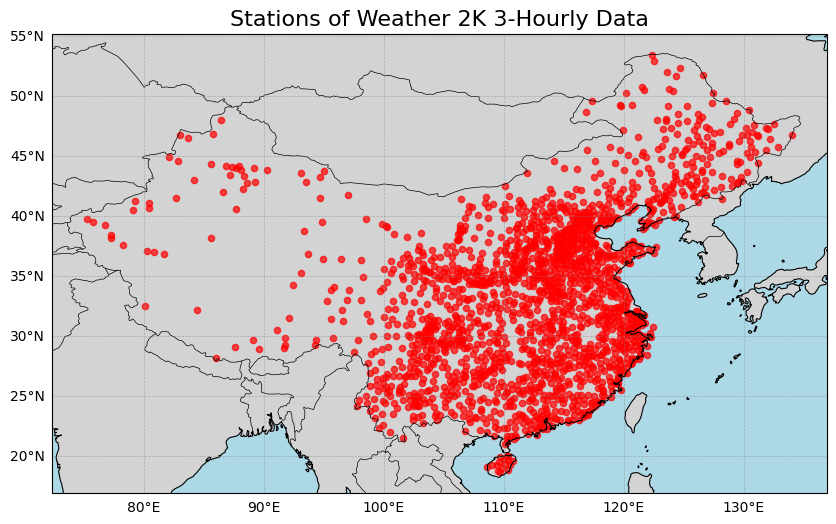

In [12]:
# plot all stations
# 抓出經緯度
lats = loc[:, 0]
lons = loc[:, 1]

# 繪圖
plt.figure(figsize=(10, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

# 加入地圖底圖
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# Add gridlines (latitude & longitude)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'fontsize': 10}
gl.ylabel_style = {'fontsize': 10}

# 畫測站點
ax.scatter(lons, lats, color="red", s=20, transform=ccrs.PlateCarree(), alpha=0.7)

plt.title("Stations of Weather 2K 3-Hourly Data", fontsize=16)
plt.show()

In [13]:
# config for sampling
seed = 42
n_loc = 200
keep_alt = False
lat_min, lat_max = -90, 90
lon_min, lon_max = -180, 180

date_start = datetime(2021, 6, 30, 21, 0, 1)
date_end = datetime(2021, 9, 1)

In [14]:
# select region
lats = loc[:, 0]
lons = loc[:, 1]
mask = (
    (lats >= lat_min) & (lats <= lat_max) &
    (lons >= lon_min) & (lons <= lon_max)
)

loc_region = loc[mask]
idx_region = np.where(mask)[0]
if not keep_alt:
    loc_region = loc_region[:, :2]
    print("已選地區 loc.shape =", loc_region.shape)
    print(f'Choosen locations:\n   lat, lon\n{loc_region}')
else:
    print("已選地區 loc.shape =", loc_region.shape)
    print(f'Choosen locations:\n   lat, lon, alt\n{loc_region}')

time_idx = np.array([i for i, t in enumerate(time_list) if date_start <= t <= date_end])
time_list = time_list[time_idx]
print("已選時間 time_idx.shape =", time_idx.shape)

已選地區 loc.shape = (1866, 2)
Choosen locations:
   lat, lon
[[ 52.97 122.51]
 [ 53.47 122.38]
 [ 52.35 124.72]
 ...
 [ 18.77 109.52]
 [ 18.65 109.7 ]
 [ 18.8  110.33]]
已選時間 time_idx.shape = (496,)


In [15]:
# sample n_loc from loc_region
np.random.seed(seed)

if n_loc > loc_region.shape[0]:
    print(f"n_loc = {n_loc} 大於已選區域格點數, 使用 {loc_region.shape[0]}")
    n_loc = loc_region.shape[0]

idx_sub = np.random.choice(loc_region.shape[0], size=n_loc, replace=False)

# 轉成 loc_all 的 index（因為後面 arr_reshaped 依據 loc_all 的展開順序）
idx_sub = np.sort(idx_sub)
idx = idx_region[idx_sub]

choosen_loc = loc_region[idx, :]
print("抽樣 choosen_loc.shape =", choosen_loc.shape)
print(f'Choosen locations:\n   lat, lon, alt\n{loc_region}')

抽樣 choosen_loc.shape = (200, 2)
Choosen locations:
   lat, lon, alt
[[ 52.97 122.51]
 [ 53.47 122.38]
 [ 52.35 124.72]
 ...
 [ 18.77 109.52]
 [ 18.65 109.7 ]
 [ 18.8  110.33]]


In [16]:
# sampled data
choosen_data = data[idx, :, :][:, time_idx, :]
print("抽樣 choosen_data.shape =", choosen_data.shape)
print(f'Choosen data:\n {choosen_data}')

抽樣 choosen_data.shape = (200, 496, 10)
Choosen data:
 [[[9.7670e+02 2.0400e+01 2.0500e+01 ... 4.3000e+00 7.7000e+01 4.3000e+00]
  [9.7640e+02 1.9300e+01 1.9700e+01 ... 4.4000e+00 7.1000e+01 4.9000e+00]
  [9.7710e+02 1.8500e+01 1.8800e+01 ... 3.9000e+00 6.8000e+01 4.8000e+00]
  ...
  [9.8600e+02 2.7300e+01 2.7600e+01 ... 2.2000e+00 2.1300e+02 2.8000e+00]
  [9.8580e+02 2.2900e+01 2.5200e+01 ... 1.8000e+00 1.8200e+02 2.7000e+00]
  [9.8620e+02 1.6900e+01 1.8200e+01 ... 1.1000e+00 1.4600e+02 1.3000e+00]]

 [[8.9160e+02 1.6600e+01 1.6600e+01 ... 3.3000e+00 1.3600e+02 4.3000e+00]
  [8.9130e+02 1.5900e+01 1.6200e+01 ... 3.3000e+00 1.4900e+02 3.6000e+00]
  [8.9110e+02 1.5700e+01 1.5700e+01 ... 3.1000e+00 1.4400e+02 3.3000e+00]
  ...
  [9.0280e+02 2.3700e+01 2.4200e+01 ... 2.5000e+00 2.3800e+02 3.7000e+00]
  [9.0250e+02 2.0000e+01 2.3400e+01 ... 8.0000e-01 2.4900e+02 2.2000e+00]
  [9.0330e+02 1.1800e+01 1.3200e+01 ... 3.0000e+00 1.4300e+02 3.4000e+00]]

 [[9.8550e+02 2.0700e+01 2.1100e+01 ... 2.

In [17]:
# config for controlling variables
keep_idx = [1]
choosen_data = choosen_data[:, :, keep_idx]
print(f'Choosen data shape: {choosen_data.shape}')

Choosen data shape: (200, 496, 1)


In [18]:
# summary
data_summary = choosen_data.copy().transpose(2, 1, 0)

# 將所有通道展平
shape = data_summary.shape
data_slice = data_summary.reshape(shape[0], shape[2] * shape[1])

df = pd.DataFrame(data_slice)

# 計算 summary
summary_df = pd.DataFrame({
    'min': df.min(axis=1),
    'max': df.max(axis=1),
    'range': df.max(axis=1) - df.min(axis=1),
    'mean': df.mean(axis=1),
    'median': df.median(axis=1),
    'std': df.std(axis=1),
    'nan_count': df.isna().sum(axis=1),
    'mode': df.mode(axis=1).iloc[:, 0]  # 取每行的第一個眾數
})

# 設定 row names
summary_df.index = [variable_list[i] for i in keep_idx]

# 顯示完整表格
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(summary_df)

                 min   max  range       mean  median       std  nan_count  \
Air Temperature -2.8  45.3   48.1  25.213847    25.6  5.541204          0   

                 mode  
Air Temperature  25.4  


In [19]:
# config for split & save
station_known = int(choosen_loc.shape[0] * 0.8)  # number of known stations in training set
hours_a_day = 8
time_train = int((len(time_list) * 0.9) // hours_a_day * hours_a_day + hours_a_day)  # number of past time steps in training set
time_future = len(time_list) - time_train  # approx 10 %
save_dir = f'./datasets'

In [20]:
time_list

array([datetime.datetime(2021, 7, 1, 0, 0),
       datetime.datetime(2021, 7, 1, 3, 0),
       datetime.datetime(2021, 7, 1, 6, 0),
       datetime.datetime(2021, 7, 1, 9, 0),
       datetime.datetime(2021, 7, 1, 12, 0),
       datetime.datetime(2021, 7, 1, 15, 0),
       datetime.datetime(2021, 7, 1, 18, 0),
       datetime.datetime(2021, 7, 1, 21, 0),
       datetime.datetime(2021, 7, 2, 0, 0),
       datetime.datetime(2021, 7, 2, 3, 0),
       datetime.datetime(2021, 7, 2, 6, 0),
       datetime.datetime(2021, 7, 2, 9, 0),
       datetime.datetime(2021, 7, 2, 12, 0),
       datetime.datetime(2021, 7, 2, 15, 0),
       datetime.datetime(2021, 7, 2, 18, 0),
       datetime.datetime(2021, 7, 2, 21, 0),
       datetime.datetime(2021, 7, 3, 0, 0),
       datetime.datetime(2021, 7, 3, 3, 0),
       datetime.datetime(2021, 7, 3, 6, 0),
       datetime.datetime(2021, 7, 3, 9, 0),
       datetime.datetime(2021, 7, 3, 12, 0),
       datetime.datetime(2021, 7, 3, 15, 0),
       datetime.dateti

In [21]:
# split data into train/test known/unknown
def check_requirement(x):
    if x % hours_a_day == 0:
        return x
    elif time_train + time_future > len(time_list):
        raise ValueError("time_train + time_future exceeds total time points")
    else:
        raise ValueError("Input (time_future) is not a day")

# generate train/test time index
past_time_amount = check_requirement(time_train)
past_time_list = time_list[:past_time_amount]
future_time_list = time_list[time_train:time_train + time_future]

past_time_idx = np.arange(time_train)            # 過去索引
future_time_idx = np.arange(time_train, time_train + time_future)  # 未來索引

## generate station masks
known_station_idx = np.random.choice(choosen_data.shape[0], station_known, replace=False)
unknown_station_idx = np.setdiff1d(np.arange(choosen_data.shape[0]), known_station_idx)

## get index positions
print("Train index range:", past_time_list[0], "→", past_time_list[-1], "(", time_train, "steps )")
print("Test index range:", future_time_list[0], "→", future_time_list[-1], "(", len(future_time_list), "steps )")

# generate known/unknown stations
print(f'Known stations: {station_known}')
print(f'Unknown stations: {choosen_data.shape[0] - station_known}')

# generate train/test data
data_train_known_real = choosen_data[:, past_time_idx, :][known_station_idx, :, :]
data_train_unknown_real = choosen_data[:, past_time_idx, :][unknown_station_idx, :, :]

data_test_known_real = choosen_data[:, future_time_idx, :][known_station_idx, :, :]
data_test_unknown_real = choosen_data[:, future_time_idx, :][unknown_station_idx, :, :]

data_train = np.concatenate([data_train_known_real, data_train_unknown_real], axis=0)
data_test = np.concatenate([data_test_known_real, data_test_unknown_real], axis=0)
data_real = np.concatenate([data_train, data_test], axis=1).transpose(2, 1, 0)

hour_list_train = past_time_list
hour_list_test = future_time_list

# generate known/unknown coords
stations_known = choosen_loc[known_station_idx, :]
stations_unknown = choosen_loc[unknown_station_idx, :]

Train index range: 2021-07-01 00:00:00 → 2021-08-25 21:00:00 ( 448 steps )
Test index range: 2021-08-26 00:00:00 → 2021-08-31 21:00:00 ( 48 steps )
Known stations: 160
Unknown stations: 40


In [22]:
print("data_train_known_real.shape =", data_train_known_real.shape)

data_train_known_real.shape = (160, 448, 1)


In [23]:
# save data
os.makedirs(save_dir, exist_ok=True)
np.save(os.path.join(save_dir, 'data.npy'), choosen_data)
np.save(os.path.join(save_dir, 'time_list.npy'), time_list)
np.save(os.path.join(save_dir, 'loc.npy'), choosen_loc)
np.save(os.path.join(save_dir, 'data_train_known_real.npy'), data_train_known_real)
np.save(os.path.join(save_dir, 'data_train_unknown_real.npy'), data_train_unknown_real)
np.save(os.path.join(save_dir, 'data_test_known_real.npy'), data_test_known_real)
np.save(os.path.join(save_dir, 'data_test_unknown_real.npy'), data_test_unknown_real)
np.save(os.path.join(save_dir, 'data_real.npy'), data_real)
np.save(os.path.join(save_dir, 'hour_list_train.npy'), hour_list_train)
np.save(os.path.join(save_dir, 'hour_list_test.npy'), hour_list_test)
np.save(os.path.join(save_dir, 'stations_known_locations.npy'), stations_known)
np.save(os.path.join(save_dir, 'stations_unknown_locations.npy'), stations_unknown)

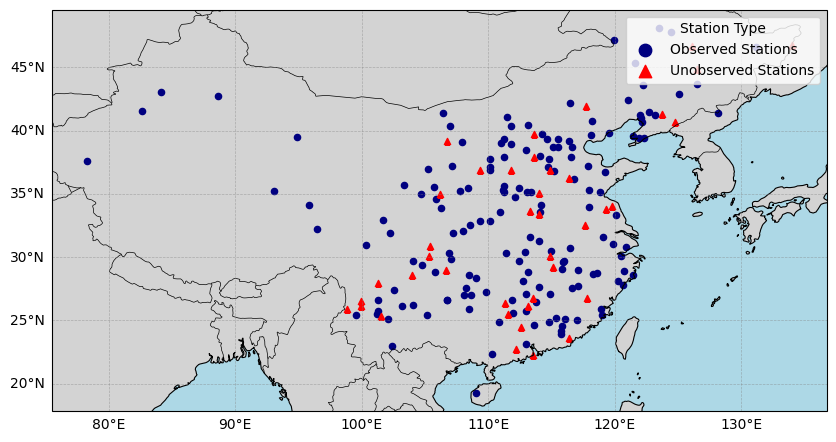

In [24]:
# plot all stations
# 繪圖
plt.figure(figsize=(10, 12))
ax = plt.axes(projection=ccrs.PlateCarree())

# 加入地圖底圖
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# Add gridlines (latitude & longitude)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'fontsize': 10}
gl.ylabel_style = {'fontsize': 10}

# 畫測站點
known_scatter = ax.scatter(
    stations_known[:, 1], stations_known[:, 0],
    color="navy", s=20, marker='o',
    transform=ccrs.PlateCarree(), alpha=1.0,
    label="Observed Stations"
)
unknown_scatter = ax.scatter(
    stations_unknown[:, 1], stations_unknown[:, 0],
    color="red", s=20, marker='^',
    transform=ccrs.PlateCarree(), alpha=1.0,
    label="Unobserved Stations"
)

plt.legend(frameon=True, loc='upper right', markerscale=2, title="Station Type")
#plt.title("Stations of Weather 2K 3-Hourly Data", fontsize=16)
#plt.tight_layout()
plt.show()